# Carregar dados e separar colunas:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

colunas = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

treino_df = pd.read_csv(r'C:\Users\kekin\OneDrive\Área de Trabalho\praicando\Sistemas inteligentes\MLP\KDDTrain+_20Percent.txt', names=colunas, header=None)
teste_df = pd.read_csv(r'C:\Users\kekin\OneDrive\Área de Trabalho\praicando\Sistemas inteligentes\MLP\KDDTest+.txt', names=colunas, header=None)

treino_df = treino_df.drop('difficulty_level', axis=1)
teste_df = teste_df.drop('difficulty_level', axis=1)

treino_df['attack_type'] = treino_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
teste_df['attack_type'] = teste_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

# Normalização e separação:

In [2]:
y_treino_total = treino_df.pop('attack_type').values
y_teste = teste_df.pop('attack_type').values

col_cat = ['protocol_type', 'service', 'flag']
col_num = [c for c in treino_df.columns if c not in col_cat]

tamanho_treino = len(treino_df)
df_combinado = pd.concat([treino_df, teste_df], axis=0)
df_combinado = pd.get_dummies(df_combinado, columns=col_cat)

X_treino_total_df = df_combinado.iloc[:tamanho_treino].copy()
X_teste_df = df_combinado.iloc[tamanho_treino:].copy()

indice_corte = int(len(X_treino_total_df) * 0.8)

X_treino_df = X_treino_total_df.iloc[:indice_corte].copy()
X_val_df = X_treino_total_df.iloc[indice_corte:].copy()

escalonador = StandardScaler()
X_treino_df[col_num] = escalonador.fit_transform(X_treino_df[col_num])
X_val_df[col_num] = escalonador.transform(X_val_df[col_num])
X_teste_df[col_num] = escalonador.transform(X_teste_df[col_num])

X_treino = X_treino_df.values.astype(np.float32)
X_val = X_val_df.values.astype(np.float32)
X_teste = X_teste_df.values.astype(np.float32)

y_treino = y_treino_total[:indice_corte].astype(np.float32)
y_val = y_treino_total[indice_corte:].astype(np.float32)
y_teste = y_teste.astype(np.float32)

# Construção da MLP:

In [3]:
class RedeMLP(nn.Module):
    def __init__(self, tam_entrada):
        super(RedeMLP, self).__init__()
        self.camada1 = nn.Linear(tam_entrada, 64)
        self.ativacao1 = nn.ReLU()
        self.camada2 = nn.Linear(64, 32)
        self.ativacao2 = nn.ReLU()
        self.saida = nn.Linear(32, 1)

    def forward(self, x):
        x = self.ativacao1(self.camada1(x))
        x = self.ativacao2(self.camada2(x))
        x = self.saida(x)
        return x

dim_entrada = X_treino.shape[1]
modelo = RedeMLP(dim_entrada)
criterio = nn.BCEWithLogitsLoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

ds_treino = TensorDataset(torch.tensor(X_treino), torch.tensor(y_treino).unsqueeze(1))
ds_val = TensorDataset(torch.tensor(X_val), torch.tensor(y_val).unsqueeze(1))
ds_teste = TensorDataset(torch.tensor(X_teste), torch.tensor(y_teste).unsqueeze(1))

loader_treino = DataLoader(ds_treino, batch_size=256, shuffle=True)
loader_val = DataLoader(ds_val, batch_size=256, shuffle=False)
loader_teste = DataLoader(ds_teste, batch_size=256, shuffle=False)

# Treino:

In [4]:
topologias = [[32], [64, 32], [128, 64, 32]]
epocas_teste = 50

for topo in topologias:
    camadas = []
    entrada_atual = X_treino.shape[1]
    
    for n in topo:
        camadas.append(nn.Linear(entrada_atual, n))
        camadas.append(nn.ReLU())
        entrada_atual = n
    camadas.append(nn.Linear(entrada_atual, 1))
    
    modelo_teste = nn.Sequential(*camadas)
    criterio_teste = nn.BCEWithLogitsLoss()
    otimizador_teste = optim.Adam(modelo_teste.parameters(), lr=0.001)
    
    for epoca in range(epocas_teste):
        modelo_teste.train()
        for batch_x, batch_y in loader_treino:
            otimizador_teste.zero_grad()
            pred = modelo_teste(batch_x)
            perda = criterio_teste(pred, batch_y)
            perda.backward()
            otimizador_teste.step()
    
    modelo_teste.eval()
    erro_val = 0.0
    with torch.no_grad():
        for batch_x, batch_y in loader_val:
            pred = modelo_teste(batch_x)
            perda = criterio_teste(pred, batch_y)
            erro_val += perda.item() * batch_x.size(0)
            
    print(f"Topologia {topo} - Loss de Validação: {erro_val / len(loader_val.dataset):.4f}")

Topologia [32] - Loss de Validação: 0.0268
Topologia [64, 32] - Loss de Validação: 0.0266
Topologia [128, 64, 32] - Loss de Validação: 0.0343


# Avaliar modelo:

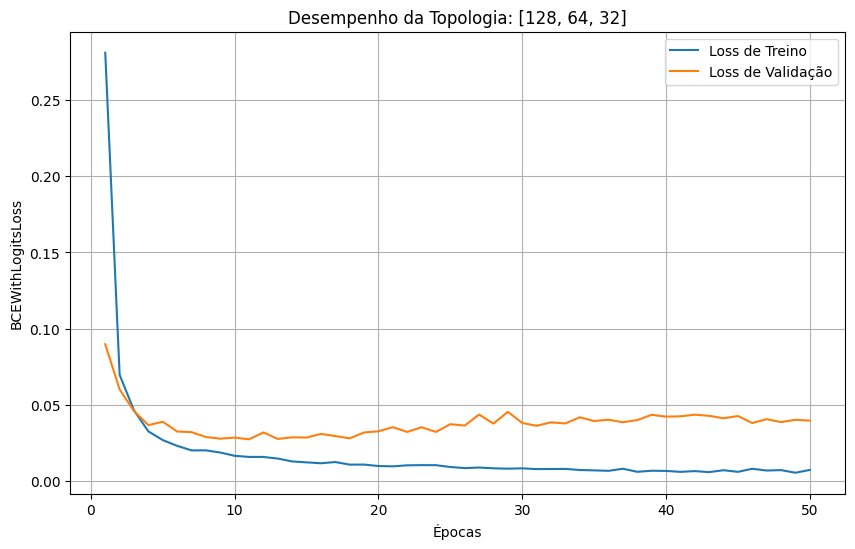

Matriz de Confusão:
 [[9034  677]
 [4246 8587]]
Acurácia: 0.7816
Precisão: 0.9269
Recall: 0.6691
F1-Score: 0.7772


In [5]:
melhor_topologia = [128, 64, 32]

camadas = []
entrada_atual = X_treino.shape[1]

for n in melhor_topologia:
    camadas.append(nn.Linear(entrada_atual, n))
    camadas.append(nn.ReLU())
    entrada_atual = n
camadas.append(nn.Linear(entrada_atual, 1))

modelo_final = nn.Sequential(*camadas)
criterio = nn.BCEWithLogitsLoss()
otimizador = optim.Adam(modelo_final.parameters(), lr=0.001)

epocas = 50
perdas_treino = []
perdas_val = []

for epoca in range(epocas):
    modelo_final.train()
    erro_treino = 0.0
    for batch_x, batch_y in loader_treino:
        otimizador.zero_grad()
        pred = modelo_final(batch_x)
        perda = criterio(pred, batch_y)
        perda.backward()
        otimizador.step()
        erro_treino += perda.item() * batch_x.size(0)
    
    perdas_treino.append(erro_treino / len(loader_treino.dataset))

    modelo_final.eval()
    erro_val = 0.0
    with torch.no_grad():
        for batch_x, batch_y in loader_val:
            pred = modelo_final(batch_x)
            perda = criterio(pred, batch_y)
            erro_val += perda.item() * batch_x.size(0)
            
    perdas_val.append(erro_val / len(loader_val.dataset))

plt.figure(figsize=(10, 6))
plt.plot(range(1, epocas + 1), perdas_treino, label='Loss de Treino')
plt.plot(range(1, epocas + 1), perdas_val, label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('BCEWithLogitsLoss')
plt.title(f'Desempenho da Topologia: {melhor_topologia}')
plt.legend()
plt.grid(True)
plt.show()


modelo_final.eval()
predicoes_finais = []
rotulos_reais = []

with torch.no_grad():
    for batch_x, batch_y in loader_teste:
        saida_bruta = modelo_final(batch_x)
        probabilidades = torch.sigmoid(saida_bruta)
        predicoes_binarias = (probabilidades >= 0.5).float() 
        predicoes_finais.extend(predicoes_binarias.squeeze().tolist())
        rotulos_reais.extend(batch_y.squeeze().tolist())


print("Matriz de Confusão:\n", confusion_matrix(rotulos_reais, predicoes_finais))
print(f"Acurácia: {accuracy_score(rotulos_reais, predicoes_finais):.4f}")
print(f"Precisão: {precision_score(rotulos_reais, predicoes_finais):.4f}")
print(f"Recall: {recall_score(rotulos_reais, predicoes_finais):.4f}")
print(f"F1-Score: {f1_score(rotulos_reais, predicoes_finais):.4f}")